# Encoder transform v5 — per-channel PR on σ-diverse (4096×16) sub-matrix

Goal: for the (4096, 16) sub-matrix of W formed from 16 columns with diverse σ_c,
compute the **participation ratio per input channel** for each of 6 transforms, using
the **per-sample local Jacobian** (autograd) — same method as `plot_encoder_function4.ipynb`.

PR_i = `(Σ_j |J[j,i]|)² / Σ_j J[j,i]²` for input channel i, averaged over samples.

Plots:
- Bar plot: PR per channel (16 channels × 6 transforms), x sorted by σ_in.
- Scatter: σ_in vs PR_i (one panel per transform).


## 0. Setup

In [1]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '6'

import sys, json, math, copy as _copy
from pathlib import Path
from collections import OrderedDict

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

notebook_dir = os.path.dirname(os.path.abspath('__file__'))
project_root = os.path.abspath(os.path.join(notebook_dir, '..'))
if project_root not in sys.path: sys.path.append(project_root)
project_root2 = os.path.abspath(os.path.join(os.getcwd(), '..', 'comp_lm_qtip'))
if project_root2 not in sys.path: sys.path.append(project_root2)

import lib.utils as utils
from NWC.models import get_model
from transformers import AutoModelForCausalLM

torch.manual_seed(0); np.random.seed(0)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

FIG_DIR = Path('/home/jgryu/workspace/weight_compression/notebooks/plot/encoder_function5')
FIG_DIR.mkdir(parents=True, exist_ok=True)
print('device', DEVICE, 'fig_dir', FIG_DIR)

W0515 15:13:46.848216 3882260 warnings.py:109] /opt/conda/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm

W0515 15:13:48.196393 3882260 warnings.py:109] /opt/conda/lib/python3.10/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: '/opt/conda/lib/python3.10/site-packages/torchvision/image.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(

W0515 15:13:49.739630 3882260 warnings.py:109] /opt/conda/lib/python3.10/site-packages/compressai/models/video/google.py:353: FutureWarning: `torch.cuda.amp.autocast(a

device cuda fig_dir /home/jgryu/workspace/weight_compression/notebooks/plot/encoder_function5


In [2]:
class Config:
    def __init__(self, **e): self.__dict__.update(e)

def load_comp_model(p):
    cfg_p = os.path.join(os.path.dirname(p), 'config.json')
    with open(cfg_p, 'r', encoding='utf-8') as fh:
        cfg = Config(**json.load(fh))
    if cfg.architecture == 'nwc_ql' and not hasattr(cfg, 'Q'): cfg.Q = 4
    if not hasattr(cfg, 'no_layernorm'): cfg.no_layernorm = False
    shift, scale = torch.empty(()), torch.empty(())
    m = get_model(cfg.architecture, cfg, scale=scale, shift=shift)
    m.config = cfg
    ckpt = torch.load(p, weights_only=False)
    scale, shift = torch.ones(1), torch.zeros(1)
    m.load_state_dict(ckpt['state_dict'], strict=False)
    try:    m.scale.copy_(scale); m.shift.copy_(shift)
    except: m.scale = scale; m.shift = shift
    m.eval(); m.update()
    return m

NWC_LLAMA_PATH = ('/home/jgryu/workspace/weight_compression/NWC/checkpoint2/nwc_ql/'
                  'block_seq_ql_random_scaler_meta-llama--Meta-Llama-3-8B__col_1024_gaussian_padding.pt/'
                  'M16/lmbda300_rdloss_ql_size16_encdim512_M16_Q4_R0_m0_batch_size2048_total_iter200000_lr0.0001_seed100/'
                  'best_loss_model_loss_5.32101_bpp_5.72603_MSE_0.00289_total_iter_95000.pth.tar')
NWC_GAUSS_PATH = ('/home/jgryu/workspace/weight_compression/NWC/checkpoint/nwc_ql/archive/'
                  'block_seq_ql_random_scaler_synthetic__gaussian_llama8b_col_1024.pt/'
                  'rdloss_ql_size16_encdim512_M16_Q4_R0_m0_batch_size2048_total_iter200000_lr0.0001_seed100/'
                  'lmbda300_/best_loss_model_loss_5.34514_bpp_5.74006_MSE_0.00294_total_iter_47500.pth.tar')

nwc       = load_comp_model(NWC_LLAMA_PATH).to(DEVICE).eval()
nwc_gauss = load_comp_model(NWC_GAUSS_PATH).to(DEVICE).eval()
BLOCK_DIM = int(nwc.input_size); M_DIM = int(nwc.M); Q_LEVEL = 1
print('NWC loaded.  block_dim=', BLOCK_DIM)

NWC loaded.  block_dim= 16


In [3]:
# Llama layer-0 q_proj
BASE_HF = '/home/jgryu/workspace/weight_compression/Wparam_dataset/hf_model/meta-llama--Meta-Llama-3-8B'
llama = AutoModelForCausalLM.from_pretrained(BASE_HF, torch_dtype='auto', low_cpu_mem_usage=True, local_files_only=True)
W_full = llama.model.layers[0].self_attn.q_proj.weight.detach().float()
W_full = W_full / W_full.std()
del llama; torch.cuda.empty_cache()
sigma_col = W_full.std(dim=0).clamp_min(1e-12)
print(f'W_full {tuple(W_full.shape)}  σ_c range=[{float(sigma_col.min()):.4f}, {float(sigma_col.max()):.4f}]')

Loading checkpoint shards: 100%|██████████| 7/7 [00:01<00:00,  5.80it/s]


W_full (4096, 4096)  σ_c range=[0.0071, 4.5543]


## 1. Six transforms

In [4]:
def make_identity_transform(): return (lambda x: x.clone())

def hadamard_matrix(n):
    H = torch.tensor([[1.0]])
    while H.shape[0] < n:
        H = torch.cat([torch.cat([H, H], 1), torch.cat([H, -H], 1)], 0)
    return H / math.sqrt(n)

def make_rht_transform(dim=BLOCK_DIM, seed=0):
    g = torch.Generator().manual_seed(seed)
    diag = (torch.randint(0, 2, (dim,), generator=g).mul(2).sub(1)).float().to(DEVICE)
    H = hadamard_matrix(dim).to(DEVICE)
    return (lambda x: (x * diag.unsqueeze(0)) @ H.T)

def make_learned_transform(model, q_level=Q_LEVEL):
    enc = model.g_a
    def f(x):
        x_in = x.unsqueeze(0).contiguous()
        ql = torch.full((1, x.shape[0]), q_level, dtype=torch.long, device=x.device)
        q_embed = model._get_q_embed(q_input=ql, reference=x_in)
        return enc(x_in, q_embed).squeeze(0)
    return f

def make_random_nwc(reference_model, seed=42):
    cfg = _copy.deepcopy(reference_model.config)
    scale, shift = torch.ones(1), torch.zeros(1)
    torch.manual_seed(seed)
    m = get_model(cfg.architecture, cfg, scale=scale, shift=shift)
    try:    m.scale.copy_(scale); m.shift.copy_(shift)
    except: m.scale = scale; m.shift = shift
    return m.eval().to(DEVICE)

nwc_random = make_random_nwc(nwc, seed=42)

TRANSFORMS = OrderedDict()
TRANSFORMS['no_transform']  = make_identity_transform()
TRANSFORMS['rht']           = make_rht_transform(dim=BLOCK_DIM, seed=0)
TRANSFORMS['learned_llama'] = make_learned_transform(nwc, q_level=Q_LEVEL)
TRANSFORMS['learned_gauss'] = make_learned_transform(nwc_gauss, q_level=Q_LEVEL)
TRANSFORMS['random_init']   = make_learned_transform(nwc_random, q_level=Q_LEVEL)
# scaling handled separately as analytical J = (1/σ_pick)·I
names_order = ['no_transform', 'scaling', 'rht', 'learned_llama', 'learned_gauss', 'random_init']
color_map = {
    'no_transform': 'tab:gray',  'scaling':       'tab:olive',
    'rht':          'tab:green', 'learned_llama': 'tab:red',
    'learned_gauss':'tab:blue',  'random_init':   'tab:orange',
}
print('transforms:', names_order)

transforms: ['no_transform', 'scaling', 'rht', 'learned_llama', 'learned_gauss', 'random_init']


## 2. (4096, 16) sub-matrix — 16 columns of W with σ-quantile-spaced σ_c

In [5]:
N_PICK = 16
sorted_cols = torch.argsort(sigma_col)
qpos = torch.linspace(0, len(sorted_cols)-1, N_PICK).round().long()
picked_cols = sorted_cols[qpos]
sigma_pick  = sigma_col[picked_cols].to(DEVICE)
W_sub       = W_full[:, picked_cols].to(DEVICE)                          # (4096, 16)
N_SAMP      = W_sub.shape[0]
print(f'σ per channel (sorted ↑): {[f"{s:.3f}" for s in sigma_pick.tolist()]}')
print(f'σ ratio max/min: {float(sigma_pick.max()/sigma_pick.min()):.1f}×   N_SAMP={N_SAMP}')

σ per channel (sorted ↑): ['0.007', '0.015', '0.022', '0.053', '0.107', '0.192', '0.665', '0.747', '0.812', '0.882', '0.976', '1.158', '1.419', '1.545', '1.715', '4.554']
σ ratio max/min: 642.1×   N_SAMP=4096


## 3. Per-sample local Jacobian (autograd) → PR per input channel

Same method as v4: `J(x_n) = ∂T(x)/∂x|_{x_n}` via `torch.autograd.functional.jacobian`,
per sample.  Then PR_i per sample → mean across samples.

For analytically-known transforms (`no_transform`, `scaling`) we skip autograd.

In [6]:
def compute_local_jacobian(T, x):
    """T: R^d → R^d.  x: (d,).  Returns J of shape (d, d)."""
    x = x.detach().requires_grad_(True)
    def func(x):
        return T(x)
    return torch.autograd.functional.jacobian(func, x)

def to_single_sample(T):
    def f(x): return T(x.unsqueeze(0)).squeeze(0)
    return f

@torch.no_grad()
def pr_per_input_channel(J_batch):
    """J_batch: (B, D, D) → (B, D) PR per input channel (= column of J)."""
    A = J_batch.abs()
    col_sum  = A.sum(dim=-2)                                              # (B, D)
    col_l2sq = (A ** 2).sum(dim=-2).clamp_min(1e-12)
    return (col_sum ** 2) / col_l2sq

eye_d = torch.eye(BLOCK_DIM, device=DEVICE)
PR_BATCH = {}                                                              # tname -> (B, 16) PR

import time
for tname in names_order:
    t0 = time.time()
    if tname == 'no_transform':
        J_batch = eye_d.unsqueeze(0).expand(N_SAMP, -1, -1).contiguous()
    elif tname == 'scaling':
        # J(x_n) = diag(1/σ_pick)  — same for all samples since σ_pick is per-channel constant
        J_const = torch.diag(1.0 / sigma_pick)                             # (16, 16)
        J_batch = J_const.unsqueeze(0).expand(N_SAMP, -1, -1).contiguous()
    else:
        f_single = to_single_sample(TRANSFORMS[tname])
        J_list = []
        for i in range(N_SAMP):
            J_list.append(compute_local_jacobian(f_single, W_sub[i]).detach())
        J_batch = torch.stack(J_list, 0)
    PR_BATCH[tname] = pr_per_input_channel(J_batch).cpu().numpy()          # (4096, 16)
    print(f'{tname:14s}  PR_batch shape={PR_BATCH[tname].shape}  '
          f'PR mean={PR_BATCH[tname].mean():.3f}  ({time.time()-t0:.1f}s)')

no_transform    PR_batch shape=(4096, 16)  PR mean=1.000  (0.1s)
scaling         PR_batch shape=(4096, 16)  PR mean=1.000  (0.0s)
rht             PR_batch shape=(4096, 16)  PR mean=16.000  (9.9s)
learned_llama   PR_batch shape=(4096, 16)  PR mean=7.680  (37.0s)
learned_gauss   PR_batch shape=(4096, 16)  PR mean=10.714  (36.8s)
random_init     PR_batch shape=(4096, 16)  PR mean=10.858  (36.8s)


## 4. Bar plot — PR per channel (16 channels × 6 transforms)

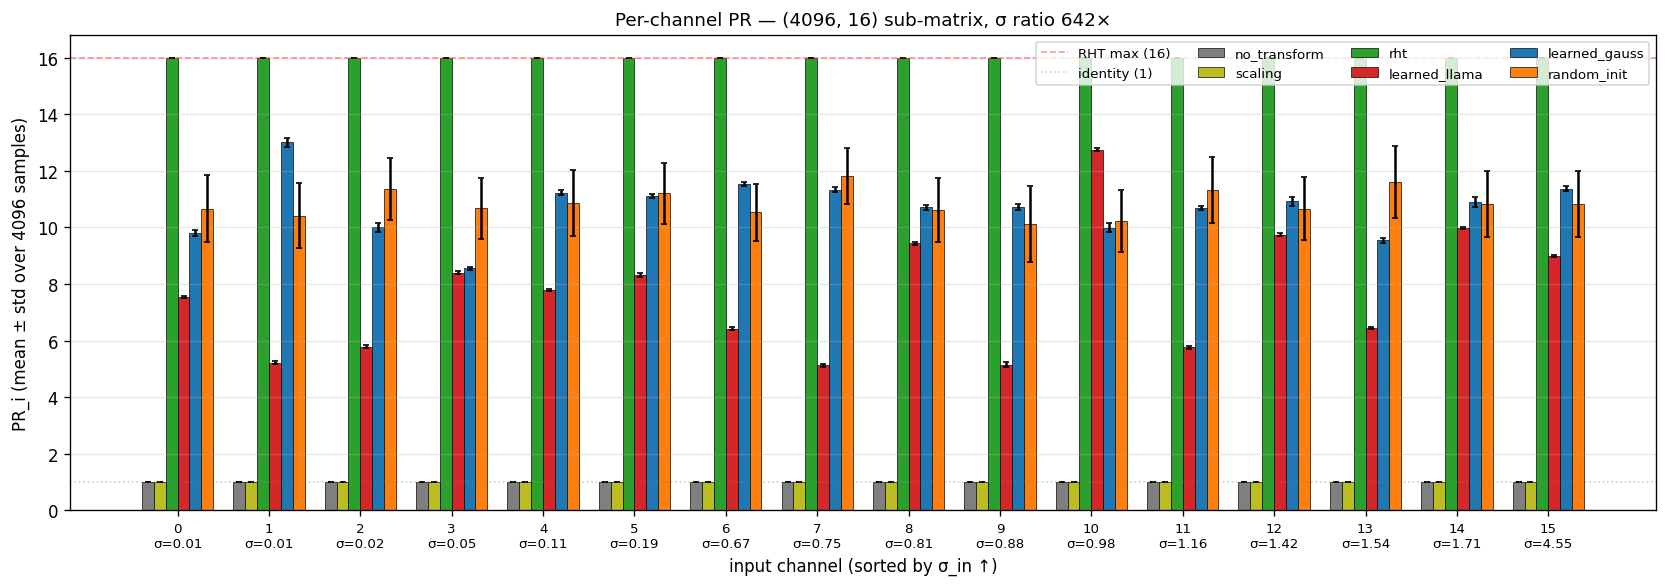

In [7]:
# Channel index already sorted by σ_in ascending.
fig, ax = plt.subplots(1, 1, figsize=(14, 5), dpi=120)
n_t = len(names_order); width = 0.13
xs = np.arange(N_PICK)
for ti, tname in enumerate(names_order):
    pr_mean = PR_BATCH[tname].mean(axis=0)                                 # (16,) mean across samples
    pr_std  = PR_BATCH[tname].std(axis=0)
    ax.bar(xs + (ti - (n_t-1)/2)*width, pr_mean, width,
           yerr=pr_std, capsize=2,
           color=color_map.get(tname, 'C0'), edgecolor='black', linewidth=0.4,
           label=tname)
ax.axhline(BLOCK_DIM, color='red', ls='--', alpha=0.4, linewidth=1.0, label=f'RHT max ({BLOCK_DIM})')
ax.axhline(1.0,       color='gray', ls=':',  alpha=0.4, linewidth=1.0, label='identity (1)')
ax.set_xticks(xs)
ax.set_xticklabels([f'{i}\nσ={float(sigma_pick[i]):.2f}' for i in range(N_PICK)], fontsize=8)
ax.set_xlabel('input channel (sorted by σ_in ↑)')
ax.set_ylabel('PR_i (mean ± std over 4096 samples)')
ax.set_title(f'Per-channel PR — (4096, 16) sub-matrix, σ ratio {float(sigma_pick.max()/sigma_pick.min()):.0f}×',
             fontsize=11)
ax.grid(True, axis='y', alpha=0.3); ax.legend(fontsize=8, ncol=4)
fig.tight_layout()
fig.savefig(FIG_DIR / 'fig01_pr_per_channel_bar.png'); plt.show()

## 5. Scatter — σ_in vs PR_i (one panel per transform)

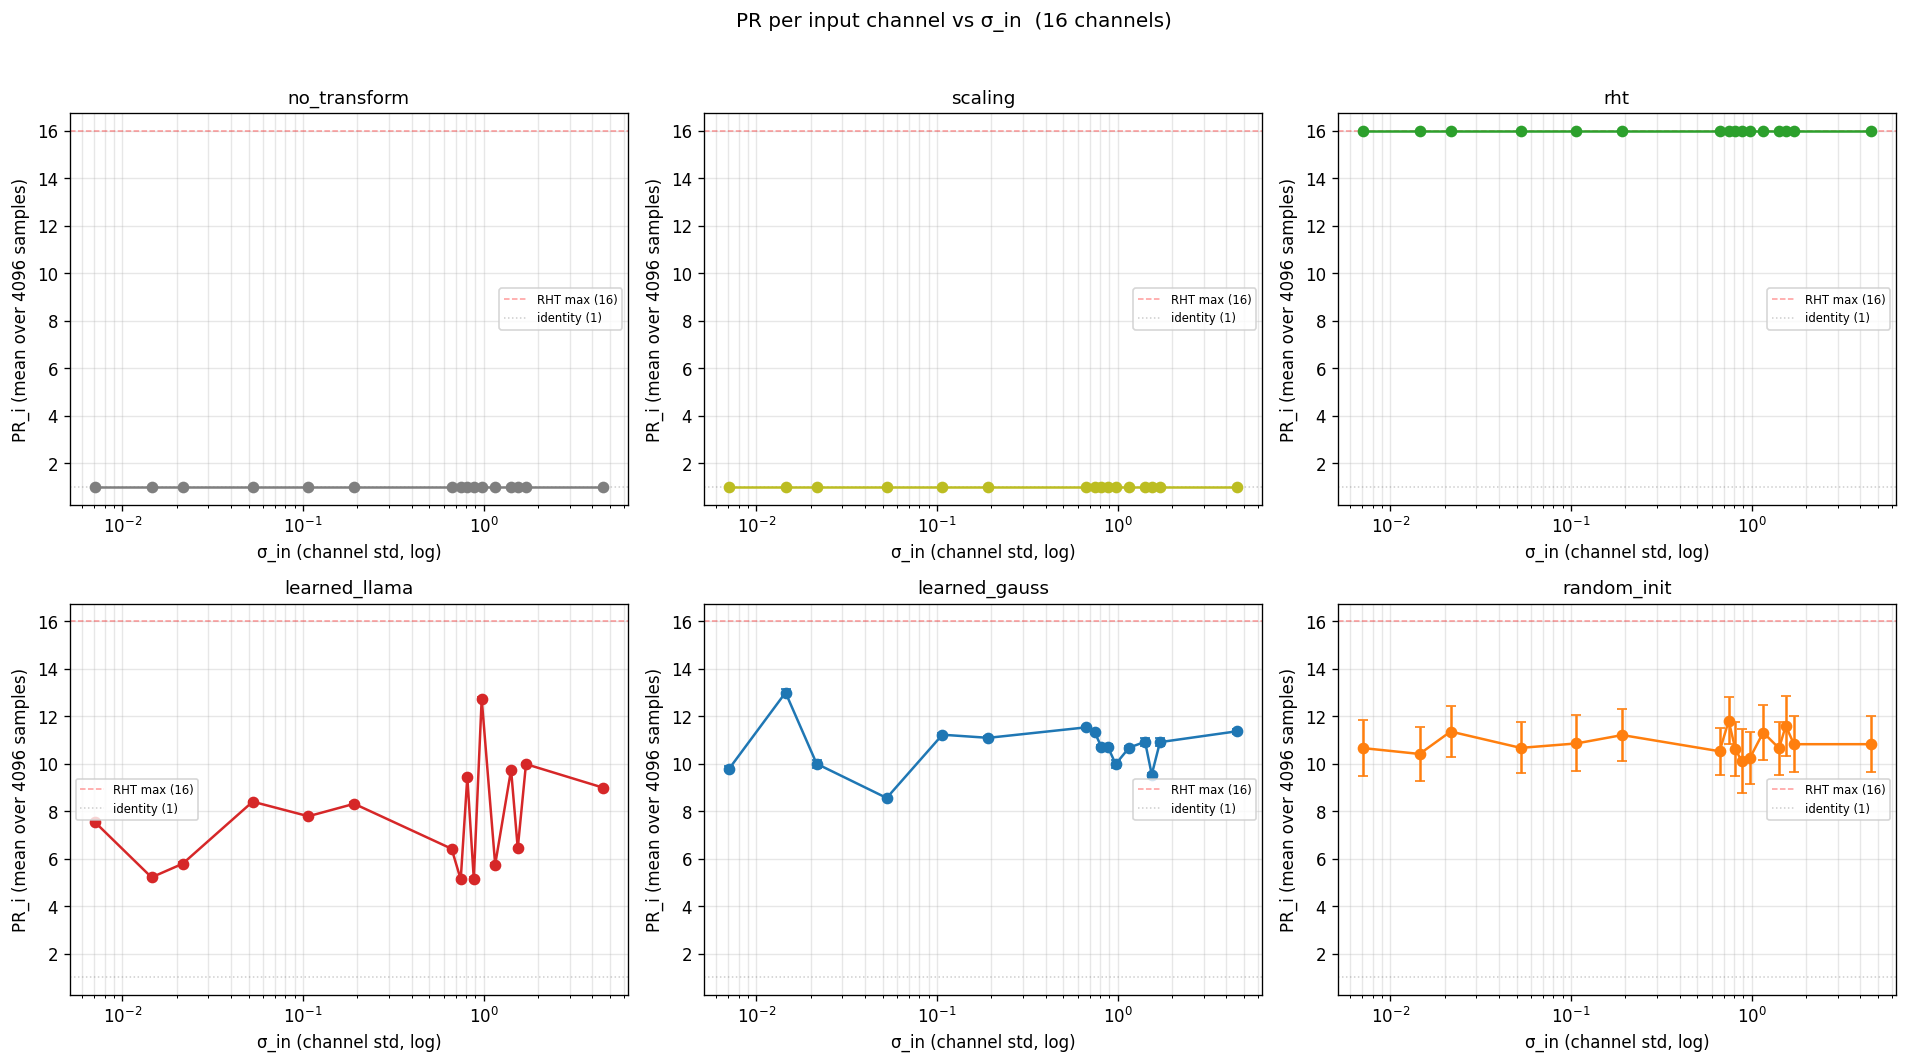

Saved → /home/jgryu/workspace/weight_compression/notebooks/plot/encoder_function5/pr_per_channel.csv  (96 rows)


In [8]:
sigma_in_np = sigma_pick.cpu().numpy()
fig, axes = plt.subplots(2, 3, figsize=(16, 9), dpi=120)
axes = axes.flatten()
for ax, tname in zip(axes, names_order):
    pr_mean = PR_BATCH[tname].mean(axis=0)                                 # (16,)
    pr_std  = PR_BATCH[tname].std(axis=0)
    ax.errorbar(sigma_in_np, pr_mean, yerr=pr_std, marker='o', linewidth=1.5, capsize=3,
                color=color_map.get(tname, 'C0'))
    ax.axhline(BLOCK_DIM, color='red', ls='--', alpha=0.4, linewidth=0.9, label=f'RHT max ({BLOCK_DIM})')
    ax.axhline(1.0,       color='gray', ls=':',  alpha=0.4, linewidth=0.9, label='identity (1)')
    ax.set_xscale('log')
    ax.set_xlabel('σ_in (channel std, log)')
    ax.set_ylabel('PR_i (mean over 4096 samples)')
    ax.set_title(tname, fontsize=11)
    ax.grid(True, which='both', alpha=0.3); ax.legend(fontsize=7, loc='best')
fig.suptitle('PR per input channel vs σ_in  (16 channels)', fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig(FIG_DIR / 'fig02_pr_vs_sigma_scatter.png'); plt.show()

# Save CSV
rows = []
for tname in names_order:
    pr_mean = PR_BATCH[tname].mean(axis=0)
    pr_std  = PR_BATCH[tname].std(axis=0)
    for i in range(N_PICK):
        rows.append({'transform': tname, 'channel': i,
                     'sigma_in': float(sigma_in_np[i]),
                     'PR_mean':  float(pr_mean[i]),
                     'PR_std':   float(pr_std[i])})
df = pd.DataFrame(rows)
df.to_csv(FIG_DIR / 'pr_per_channel.csv', index=False)
print(f'Saved → {FIG_DIR}/pr_per_channel.csv  ({len(df)} rows)')

## 6. Extend to all columns — 256 consecutive 16-column groups

Same analysis as §2-§5, but applied to **256 disjoint groups of 16 consecutive columns**:
- Group g → columns `[16g, 16g+15]` → sub-matrix of shape `(4096, 16)`
- For each group: compute per-sample local Jacobian on N_SAMP samples (rows), get PR per input channel
- Each column index c ∈ [0, 4095] thus has its own per-channel PR, in the context of the group it belongs to (channel k = c % 16 of group g = c // 16)

Plot: scatter of σ_c vs PR_c (4096 points per transform, 6 panels).

In [9]:
# 6a. Loop over 256 groups, compute PR per channel per group.
N_GROUPS = W_full.shape[1] // BLOCK_DIM           # 256
N_SAMP_PER_GROUP = 128                             # subsample of 4096 rows for autograd speed
print(f'N_GROUPS={N_GROUPS}  N_SAMP_PER_GROUP={N_SAMP_PER_GROUP}  '
      f'autograd Jacobians per transform = {N_GROUPS * N_SAMP_PER_GROUP}')

torch.manual_seed(0)
PR_PER_COL = {}                                    # tname -> (N_COLS=4096,) per-column PR
import time

for tname in names_order:
    t0 = time.time()
    pr_per_col_arr = np.zeros(W_full.shape[1])     # (4096,)
    for g in range(N_GROUPS):
        cols = torch.arange(g*BLOCK_DIM, (g+1)*BLOCK_DIM)
        W_g = W_full[:, cols].to(DEVICE)           # (4096, 16)
        sigma_g = sigma_col[cols].to(DEVICE)       # (16,)
        row_idx = torch.randperm(W_g.shape[0])[:N_SAMP_PER_GROUP].to(DEVICE)
        X_g = W_g[row_idx]                         # (N_SAMP_PER_GROUP, 16)

        if tname == 'no_transform':
            J_b = eye_d.unsqueeze(0).expand(N_SAMP_PER_GROUP, -1, -1).contiguous()
        elif tname == 'scaling':
            J_const = torch.diag(1.0 / sigma_g)    # (16, 16)
            J_b = J_const.unsqueeze(0).expand(N_SAMP_PER_GROUP, -1, -1).contiguous()
        else:
            f_single = to_single_sample(TRANSFORMS[tname])
            J_list = [compute_local_jacobian(f_single, X_g[i]).detach() for i in range(N_SAMP_PER_GROUP)]
            J_b = torch.stack(J_list, 0)
        pr_b = pr_per_input_channel(J_b).mean(dim=0).cpu().numpy()  # (16,) mean over samples
        pr_per_col_arr[cols.numpy()] = pr_b
    PR_PER_COL[tname] = pr_per_col_arr
    print(f'  {tname:14s}  PR mean={pr_per_col_arr.mean():.3f}  std={pr_per_col_arr.std():.3f}  '
          f'({time.time()-t0:.1f}s)')

N_GROUPS=256  N_SAMP_PER_GROUP=128  autograd Jacobians per transform = 32768


  no_transform    PR mean=1.000  std=0.000  (1.5s)
  scaling         PR mean=1.000  std=0.000  (1.5s)
  rht             PR mean=16.000  std=0.000  (88.1s)
  learned_llama   PR mean=7.672  std=2.099  (303.4s)
  learned_gauss   PR mean=10.710  std=0.978  (304.7s)
  random_init     PR mean=10.805  std=0.409  (305.5s)


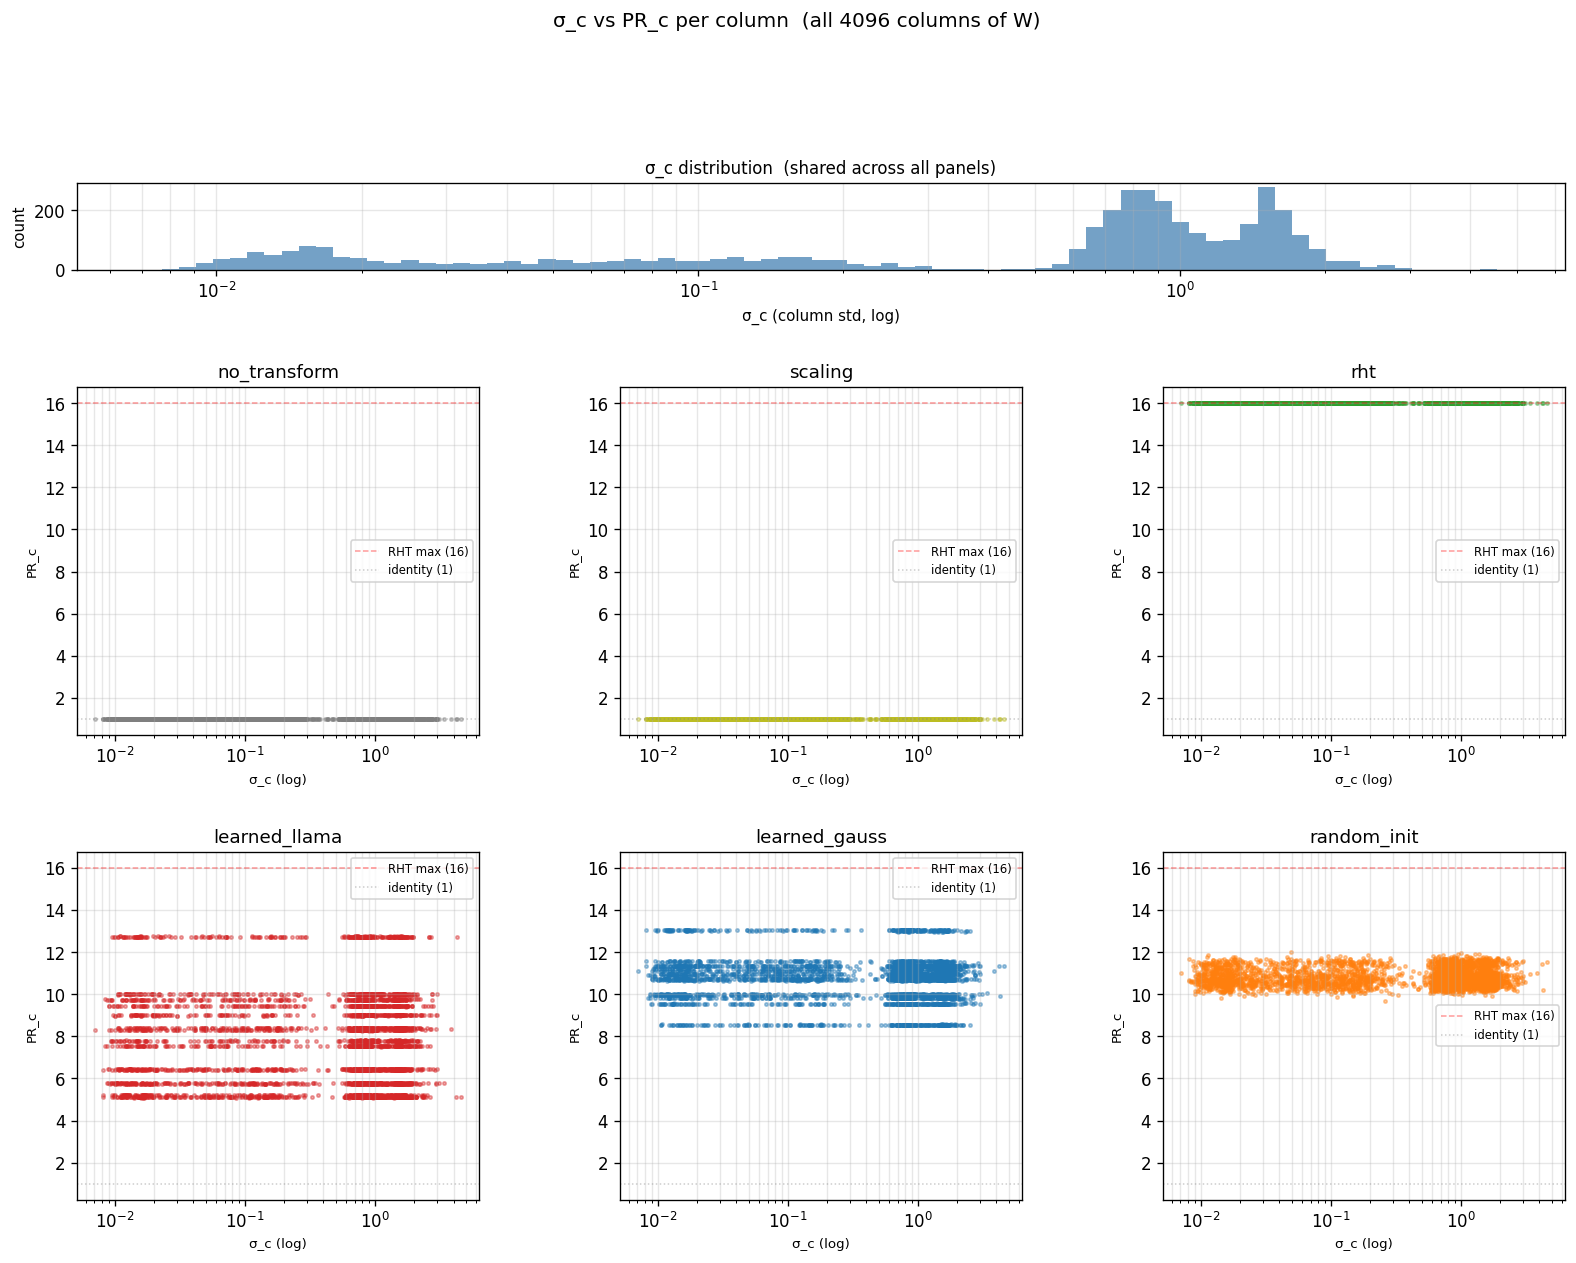

Saved → /home/jgryu/workspace/weight_compression/notebooks/plot/encoder_function5/pr_per_col.csv  (4096 rows)

transform        PR mean    PR std  corr(log σ, PR)
no_transform       1.000     0.000            0.000
scaling            1.000     0.000            0.000
rht               16.000     0.000            0.000
learned_llama      7.672     2.099            0.007
learned_gauss     10.710     0.978           -0.029
random_init       10.805     0.409            0.025


In [10]:
# 6b. Scatter σ_c vs PR_c — 4096 points per transform.
# Top row: shared σ_c density histogram (log-scale x); bottom 2 rows: scatter panels.
import matplotlib.gridspec as gridspec

sigma_c_np = sigma_col.cpu().numpy()

fig = plt.figure(figsize=(16, 11), dpi=120)
gs = gridspec.GridSpec(3, 3, height_ratios=[1, 4, 4], hspace=0.45, wspace=0.35)

# ── shared σ_c histogram (spans all 3 columns) ─────────────────────────────
ax_hist = fig.add_subplot(gs[0, :])
log_bins = np.logspace(np.log10(sigma_c_np.min()), np.log10(sigma_c_np.max()), 80)
ax_hist.hist(sigma_c_np, bins=log_bins, color='steelblue', alpha=0.75, edgecolor='none')
ax_hist.set_xscale('log')
ax_hist.set_xlabel('σ_c (column std, log)', fontsize=9)
ax_hist.set_ylabel('count', fontsize=9)
ax_hist.set_title('σ_c distribution  (shared across all panels)', fontsize=10)
ax_hist.grid(True, which='both', alpha=0.3)

# ── scatter panels ──────────────────────────────────────────────────────────
scatter_positions = [(1, 0), (1, 1), (1, 2), (2, 0), (2, 1), (2, 2)]
for (row, col), tname in zip(scatter_positions, names_order):
    ax = fig.add_subplot(gs[row, col])
    pr_arr = PR_PER_COL[tname]
    ax.scatter(sigma_c_np, pr_arr, s=4, alpha=0.4, color=color_map.get(tname, 'C0'))
    ax.axhline(BLOCK_DIM, color='red',  ls='--', alpha=0.4, linewidth=0.9, label=f'RHT max ({BLOCK_DIM})')
    ax.axhline(1.0,       color='gray', ls=':',  alpha=0.4, linewidth=0.9, label='identity (1)')
    ax.set_xscale('log')
    ax.set_xlabel('σ_c (log)', fontsize=8)
    ax.set_ylabel('PR_c',      fontsize=8)
    ax.set_title(tname, fontsize=11)
    ax.grid(True, which='both', alpha=0.3)
    ax.legend(fontsize=7)

fig.suptitle(f'σ_c vs PR_c per column  (all {W_full.shape[1]} columns of W)', fontsize=12, y=1.01)
fig.savefig(FIG_DIR / 'fig03_pr_vs_sigma_all_cols.png', bbox_inches='tight')
plt.show()

# Save CSV
df_all = pd.DataFrame({'col': np.arange(W_full.shape[1]), 'sigma_c': sigma_c_np})
for tname in names_order:
    df_all[f'{tname}_PR'] = PR_PER_COL[tname]
df_all.to_csv(FIG_DIR / 'pr_per_col.csv', index=False)
print(f'Saved → {FIG_DIR}/pr_per_col.csv  ({len(df_all)} rows)')

# Stats
print(f"\n{'transform':<14} {'PR mean':>9} {'PR std':>9} {'corr(log σ, PR)':>16}")
for tname in names_order:
    pr_arr = PR_PER_COL[tname]
    corr = np.corrcoef(np.log(sigma_c_np), pr_arr)[0, 1] if pr_arr.std() > 0 else 0.0
    print(f'{tname:<14}  {pr_arr.mean():>8.3f}  {pr_arr.std():>8.3f}  {corr:>15.3f}')
